In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ImtaTURB as imta

In [2]:
# Creación de vector con ángulos (0 a 350  @ 10)
angulos_deg = np.arange(0, 360, 10) # [0,10,20 ..., 350]
angulos_rad = np.radians(angulos_deg) # Conversión a radianes
dtheta = angulos_rad[1]-angulos_rad[0] # Paso de ángulo
print(angulos_deg)

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170
 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350]


In [3]:
# 4 planos de 20 pilas @ plano = 80 cilindros
num_cil = 2 # Número de cilindros
allprobes = np.arange(0, num_cil , 1) # [0,10,20 ..., 350]
print(allprobes)
for probe_i in allprobes:
    puntos_i = list(range(probe_i*angulos_deg.size, probe_i*angulos_deg.size+angulos_deg.size))
    print(f'Cilindro {probe_i+1}')
    print(puntos_i)

[0 1]
Cilindro 1
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Cilindro 2
[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]


In [4]:
# === Datos del caso ===
rho = 1000.0            # kg/m^3
U_inf = 0.177           # m/s
D = 0.05                # m
R = D / 2               # m
span = 0.26             # m (altura de la pila)

# Archivo de presión
file_p = "Datos/OpenFOAM/20_cm/p_1"

c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 168 probes.
Tiempo inicial: 0.00 s, tiempo final: 200.00 s
Duración de la muestra: 200.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


ValueError: x and y must have same first dimension, but have shapes (36,) and (35,)

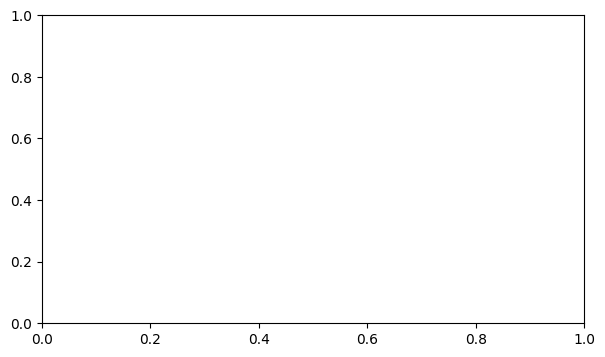

In [5]:
# Probes alrededor de cada cilindro
# Aguas arriba: 10° en probe 25, 360° en 59 (cada 10°)
up_ini = 25
up_fin = 59

# Aguas abajo: 10° en probe 96, 360° en 130 (cada 10°)
down_ini = 96
down_fin = 130

# === Cargar presión ===
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)

# === Función auxiliar: Cp promedio vs theta ===
def cp_promedio_por_theta(p_probes, probes_ordenados, rho, U_inf, t_ini=None):
    series_p = []
    for prb in probes_ordenados:
        p_i, t_i, _ = imta.recortar_tiempo(
            p_probes, probe=prb,
            inicio=tiempo_p.iloc[0] if t_ini is None else t_ini
        )
        series_p.append(p_i.values)

    p_theta = np.vstack(series_p).T  # (n_tiempos, n_angulos)
    p_pa = rho * p_theta             # convertir a Pa (p en m^2/s^2)

    # Promedio temporal por ángulo
    p_mean = np.mean(p_pa, axis=0)

    # Cp = p / (0.5*rho*U_inf^2) (sin p_inf)
    q = 0.5 * rho * U_inf**2
    Cp = p_mean / q

    return Cp, p_pa

# === Cp para cilindro aguas arriba ===
probes_up = list(range(up_ini, up_fin + 1))
Cp_up, p_pa_up = cp_promedio_por_theta(p_probes, probes_up, rho, U_inf)

# === Cp para cilindro aguas abajo ===
probes_down = list(range(down_ini, down_fin + 1))
Cp_down, p_pa_down = cp_promedio_por_theta(p_probes, probes_down, rho, U_inf)

# === Gráfica Cp vs theta ===
plt.figure(figsize=(7, 4))
plt.plot(angulos_deg, Cp_up, 'o-', label='Cilindro aguas arriba')
plt.plot(angulos_deg, Cp_down, 's-', label='Cilindro aguas abajo')
plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$C_p$')
plt.title('Distribución de presión promedio en la superficie (20 cm)')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()

# === Función para CD, CL, CM por integración ===
def coeficientes_from_p(p_pa, theta, rho, U_inf, R, D, span):
    # p_pa: (n_tiempos, n_angulos)
    nx = np.cos(theta)
    nz = np.sin(theta)

    # Fuerzas por unidad de longitud
    Fx = -np.sum(p_pa * nx, axis=1) * R * dtheta  # N/m
    Fz = -np.sum(p_pa * nz, axis=1) * R * dtheta  # N/m

    # Convertir a fuerza total 3D
    Fx_total = Fx * span
    Fz_total = Fz * span

    # Coeficientes
    A = D * span
    q = 0.5 * rho * U_inf**2
    CD = Fx_total / (q * A)
    CL = Fz_total / (q * A)

    # Momento respecto al centro (eje y)
    x_r = R * np.cos(theta)
    z_r = R * np.sin(theta)

    dFx = -(p_pa * nx) * R * dtheta
    dFz = -(p_pa * nz) * R * dtheta

    My = np.sum(x_r * dFz - z_r * dFx, axis=1)  # N/m
    My_total = My * span
    CM = My_total / (q * A * D)

    return CD, CL, CM

# === CD, CL, CM para cada cilindro ===
CD_up, CL_up, CM_up = coeficientes_from_p(p_pa_up, angulos_rad, rho, U_inf, R, D, span)
CD_down, CL_down, CM_down = coeficientes_from_p(p_pa_down, angulos_rad, rho, U_inf, R, D, span)

# === Promedios ===
print(f"Upstream CD promedio: {np.mean(CD_up):.5f}")
print(f"Upstream CL promedio: {np.mean(CL_up):.5f}")
print(f"Upstream CM promedio: {np.mean(CM_up):.5f}")
print("-" * 40)
print(f"Downstream CD promedio: {np.mean(CD_down):.5f}")
print(f"Downstream CL promedio: {np.mean(CL_down):.5f}")
print(f"Downstream CM promedio: {np.mean(CM_down):.5f}")